In [1]:
import sys 
sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
from controllers.mpc_01 import MpcController
from sim.runner import run_tracking,  tracking_metrics,  settling_times
from sim.trajectories import circle_ref, figure8_ref, waypoint_ref

/Users/yashralhan/Projects/holonomic-control-benchmark/.venv/lib/python3.11/site-packages/do_mpc/sysid/__init__.py:15: UserWarning: The ONNX feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The ONNX feature is not available. Please install the full version of do-mpc to access this feature.')
/Users/yashralhan/Projects/holonomic-control-benchmark/.venv/lib/python3.11/site-packages/do_mpc/opcua/__init__.py:14: UserWarning: The opcua feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The opcua feature is not available. Please install the full version of do-mpc to access this feature.')



******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

{'pos_rmse': 0.045107283506284374, 'heading_rmse': 0.011170924386236451, 'effort': 14900.833860280325, 'compute_ms_mean': 2.7181597084272653, 'compute_ms_max': 32.0921249804087}


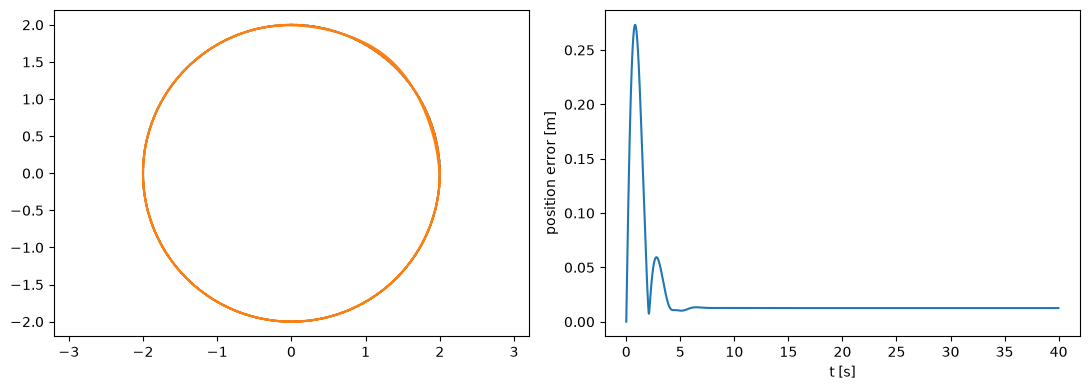

In [2]:
dt = 0.02
mpc = MpcController(circle_ref, dt)
res = run_tracking(mpc, circle_ref, 40.0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(res["ref"][:, 0], res["ref"][:, 1], "--")
axes[0].plot(res["states"][:, 0], res["states"][:, 1])
axes[0].axis("equal")
err = np.linalg.norm(res["states"][:, :2] - res["ref"][:, :2], axis=1)
axes[1].plot(res["t"], err)
axes[1].set(xlabel="t [s]", ylabel="position error [m]")
plt.tight_layout()
print(tracking_metrics(res))

In [3]:
runs = [
    ("circle", circle_ref, 40.0),
    ("figure8", figure8_ref, 60.0),
    ("waypoints", lambda t: waypoint_ref(t, hold=8.0), 40.0),
]
rows = []
for name, ref_fn, duration in runs:
    ctrl = MpcController(ref_fn, dt)
    res = run_tracking(ctrl, ref_fn, duration)
    rows.append({"controller": "mpc", "trajectory": name, **tracking_metrics(res)})

df = pd.DataFrame(rows)
df.to_csv("../results/mpc_nominal.csv", index=False)
df


,controller,trajectory,pos_rmse,heading_rmse,effort,compute_ms_mean,compute_ms_max
0,mpc,circle,0.045107,0.011171,14900.833860,2.737632,39.105875
1,mpc,figure8,0.032075,0.007560,11912.105294,2.651914,22.721667
2,mpc,waypoints,0.216489,0.000120,39837.221490,2.819423,21.689250


In [4]:
pid_df = pd.read_csv("../results/pid_nominal.csv")
pd.concat([pid_df, df]).sort_values(["trajectory", "controller"])


,controller,trajectory,pos_rmse,heading_rmse,effort,compute_ms_mean,compute_ms_max
0,mpc,circle,0.045107,1.117092e-02,14900.833860,2.737632,39.105875
0,pid,circle,0.301985,1.442013e-01,16307.545806,0.010444,0.879125
1,mpc,figure8,0.032075,7.560366e-03,11912.105294,2.651914,22.721667
1,pid,figure8,0.188251,1.395273e-01,12955.661897,0.008808,0.082208
2,mpc,waypoints,0.216489,1.200614e-04,39837.221490,2.819423,21.689250
2,pid,waypoints,0.658036,2.281976e-16,11510.396359,0.008802,0.042791


In [5]:
ctrl = MpcController(lambda t: waypoint_ref(t, hold=8.0), dt)
res = run_tracking(ctrl, lambda t: waypoint_ref(t, hold=8.0), 40.0)
settling_times(res)


[nan, nan, nan, np.float64(2.46)]